In [ ]:
import os

# Polars
os.environ["POLARS_MAX_THREADS"] = "1"

# PyArrow
os.environ["ARROW_NUM_THREADS"] = "1"

# BLAS / OpenMP (NumPy / Pandas / SciPy / sklearn backend)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [2]:
import polars as pl
import plotly.graph_objects as go
import plotly.express as px

df = pl.scan_csv("./output/bang_diem_to_hop_2025.csv")
df.head(7).collect()

SOBAODANH,Tổ hợp,Tổng điểm,Hợp lệ,Chương trình mới
i64,str,f64,bool,bool
1000001,"""C02""",21.25,true,true
1000001,"""B03""",21.75,true,true
1000001,"""B00""",21.75,true,true
1000001,"""C08""",23.75,true,true
1000002,"""C01""",24.75,true,true
1000002,"""C02""",23.0,true,true
1000002,"""A00""",23.25,true,true


In [3]:
TO_HOP = pl.scan_csv("./input/bang_to_hop_mon.csv").with_columns(
    (
        pl.col("Tổ hợp") +
        pl.lit(" (") +
        pl.col("Môn 1") +
        pl.lit(", ") +
        pl.col("Môn 2") +
        pl.lit(", ") +
        pl.col("Môn 3") +
        pl.lit(") ")
    ).alias("Tên tổ hợp")
)
TO_HOP.head().collect()

Môn 1,Môn 2,Môn 3,Tổ hợp,Tên tổ hợp
str,str,str,str,str
"""Toán""","""Lí""","""Hóa""","""A00""","""A00 (Toán, Lí, Hóa) """
"""Toán""","""Lí""","""Anh""","""A01""","""A01 (Toán, Lí, Anh) """
"""Toán""","""Lí""","""Sinh""","""A02""","""A02 (Toán, Lí, Sinh) """
"""Toán""","""Lí""","""Sử""","""A03""","""A03 (Toán, Lí, Sử) """
"""Toán""","""Lí""","""Địa""","""A04""","""A04 (Toán, Lí, Địa) """


In [4]:
# Cho phép hiển thị tất cả các cột, không bị giới hạn chiều ngang
pl.Config.set_tbl_cols(-1)

# Cho phép hiển thị độ dài nội dung trong mỗi ô nhiều hơn (ví dụ 100 ký tự)
# để không bị cắt bớt tên tổ hợp dài
pl.Config.set_fmt_str_lengths(100)

# Hiển thị số dòng tối đa bạn muốn (ví dụ 20 dòng cho bảng Top 20)
pl.Config.set_tbl_rows(20)

polars.config.Config

# Thống kê cơ bản về tính hợp lệ

In [26]:
valid_table = df.group_by("SOBAODANH").agg([
    pl.col("Hợp lệ").all().first().fill_null(False)
])

valid_table.head().collect()

SOBAODANH,Hợp lệ
str,bool
"""02029631""",true
"""26023928""",true
"""29003926""",true
"""54010169""",true
"""45004674""",true


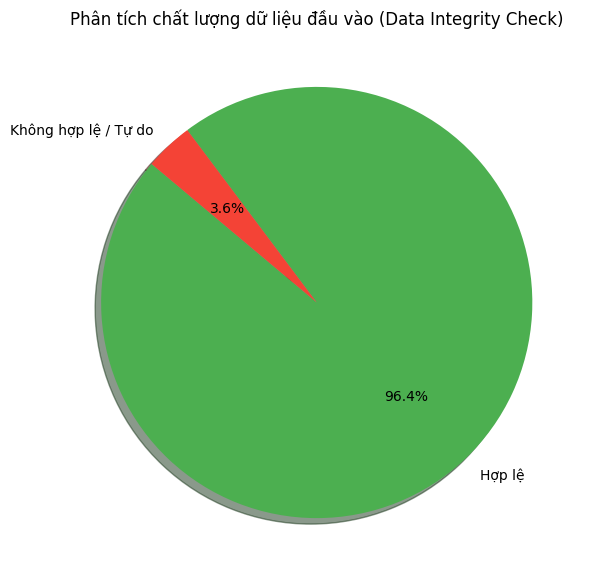

In [31]:
# 2. Tính toán tỷ lệ để vẽ biểu đồ
status_counts = valid_table.select(
    total = pl.len(),
    valid = pl.col("Hợp lệ").sum(),
    invalid = pl.col("Hợp lệ").not_().sum()
).collect()

# 3. Vẽ biểu đồ tròn
import matplotlib.pyplot as plt

labels = ['Hợp lệ', 'Không hợp lệ / Tự do']
sizes = [status_counts["valid"][0], status_counts["invalid"][0]]
colors = ['#4CAF50', '#F44336'] # Xanh lá cho 'đạt', Đỏ cho 'loại'

plt.figure(figsize=(10, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=colors, shadow=True)
plt.title("Phân tích chất lượng dữ liệu đầu vào (Data Integrity Check)")
plt.show()

# Thống kê số bạn chọn theo tổ hợp

In [5]:
stat_1 = (
    df.group_by("Tổ hợp")
        .agg(pl.len().alias("Số lượng")) # Dùng agg để rút gọn len + alias
        .join(
            TO_HOP.select(["Tổ hợp", "Tên tổ hợp"]),
            on = "Tổ hợp",
            how = "left"
        )
        .sort(by = "Số lượng", descending = True) # Đưa Sort xuống sau Join
)

print(stat_1.drop("Tổ hợp").head(20).collect())

shape: (20, 2)
┌──────────┬─────────────────────────────────────────────────┐
│ Số lượng ┆ Tên tổ hợp                                      │
│ ---      ┆ ---                                             │
│ u32      ┆ str                                             │
╞══════════╪═════════════════════════════════════════════════╡
│ 481293   ┆ C03 (Văn, Toán, Sử)                             │
│ 476472   ┆ C04 (Văn, Toán, Địa)                            │
│ 351848   ┆ D01 (Toán, Văn, Anh)                            │
│ 347599   ┆ C01 (Văn, Toán, Lí)                             │
│ 297403   ┆ A07 (Toán, Sử, Địa)                             │
│ 297403   ┆ C00 (Văn, Sử, Địa)                              │
│ 246401   ┆ X01 (Văn, Toán, Giáo dục kinh tế và pháp luật)  │
│ 246401   ┆ C14 (Văn, Toán, Giáo dục kinh tế và pháp luật)  │
│ 240135   ┆ C02 (Văn, Toán, Hóa)                            │
│ 162206   ┆ C05 (Văn, Lí, Hóa)                              │
│ 162206   ┆ A00 (Toán, Lí, Hóa)        

# Thống kê phổ điểm chung và số lượng bạn tại các tổ hợp phổ biến (A00, A01, B00, C00, C01, D01, X01)

In [6]:
import polars as pl
import plotly.express as px

# 1. Định nghĩa danh sách 10 tổ hợp chiến lược
chien_luoc = ["A00", "A01", "B00", "C00", "C01", "D01", "D07", "X01"]

# 2. Xử lý dữ liệu bằng LazyFrame (scan_csv)
df_plot = (
    pl.scan_csv("./output/bang_diem_to_hop_2025.csv")
    .filter(pl.col("Tổ hợp").is_in(chien_luoc))
    .filter(pl.col("Hợp lệ") == True)
    .select(["Tổ hợp", "Tổng điểm"])
    .collect() # Thực thi tính toán
)

# 3. Vẽ Box Plot
fig = px.box(
    df_plot.to_pandas(),
    x="Tổ hợp",
    y="Tổng điểm",
    color="Tổ hợp",
    category_orders={"Tổ hợp": chien_luoc},
    title="Phân tích điểm thi của 10 Tổ hợp Chiến lược 2025",
    points="outliers",
    orientation = "v",
    template="plotly_white"
)

# Tinh chỉnh giao diện
fig.update_layout(
    xaxis_title="Tổ hợp xét tuyển",
    yaxis_title="Tổng điểm 3 môn",
    hovermode="closest"
)

fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [7]:
print(
    pl.scan_csv("./output/bang_diem_to_hop_2025.csv")
    .filter(pl.col("Tổ hợp").is_in(chien_luoc))
    .filter(pl.col("Hợp lệ") == True)
    .group_by("Tổ hợp")
    .agg([
        pl.len().alias("Số lượng"),
        pl.col("Tổng điểm").mean().alias("Trung bình"),
        pl.col("Tổng điểm").median().alias("Trung vị"),
        pl.col("Tổng điểm").std().alias("Độ lệch chuẩn"),
        pl.col("Tổng điểm").quantile(0.25).alias("Q1"),
        pl.col("Tổng điểm").quantile(0.75).alias("Q3"),
        pl.col("Tổng điểm").skew().alias("Độ lệch (Skew)"),
    ])
    .sort("Trung vị", descending=True)
    .collect()
)

shape: (8, 8)
┌────────┬──────────┬────────────┬──────────┬───────────────┬───────┬───────┬────────────────┐
│ Tổ hợp ┆ Số lượng ┆ Trung bình ┆ Trung vị ┆ Độ lệch chuẩn ┆ Q1    ┆ Q3    ┆ Độ lệch (Skew) │
│ ---    ┆ ---      ┆ ---        ┆ ---      ┆ ---           ┆ ---   ┆ ---   ┆ ---            │
│ str    ┆ u32      ┆ f64        ┆ f64      ┆ f64           ┆ f64   ┆ f64   ┆ f64            │
╞════════╪══════════╪════════════╪══════════╪═══════════════╪═══════╪═══════╪════════════════╡
│ C01    ┆ 341963   ┆ 20.07974   ┆ 20.1     ┆ 3.24138       ┆ 17.85 ┆ 22.5  ┆ -0.164064      │
│ C00    ┆ 292489   ┆ 19.697232  ┆ 19.85    ┆ 4.246346      ┆ 16.6  ┆ 23.0  ┆ -0.201917      │
│ A00    ┆ 160491   ┆ 19.374255  ┆ 19.25    ┆ 4.334228      ┆ 16.1  ┆ 22.7  ┆ 0.028012       │
│ A01    ┆ 146104   ┆ 18.872439  ┆ 18.75    ┆ 3.62112       ┆ 16.25 ┆ 21.5  ┆ 0.000633       │
│ X01    ┆ 244167   ┆ 18.452617  ┆ 18.6     ┆ 2.968719      ┆ 16.6  ┆ 20.5  ┆ -0.283812      │
│ D01    ┆ 349692   ┆ 18.584643  ┆ 1

In [8]:
df_group_by = (
    pl.scan_csv("./output/bang_diem_to_hop_2025.csv")
    .filter(pl.col("Tổ hợp").is_in(chien_luoc))
    .filter(pl.col("Hợp lệ") == True)
    .group_by("Tổ hợp")
    .count()
    .rename({"count" : "Số lượng"})
    .sort(by = "Tổ hợp", descending = False)
    .collect()
)

df_group_by

/tmp/ipykernel_42295/2691083797.py:6: DeprecationWarning:

`count` was renamed; use `len` instead



Tổ hợp,Số lượng
str,u32
"""A00""",160491
"""A01""",146104
"""B00""",43685
"""C00""",292489
"""C01""",341963
"""D01""",349692
"""D07""",24388
"""X01""",244167


## Phân tích phổ điểm năm 2025

Về kết quả thi:

| Tổ hợp | Số lượng (n) | Chỉ số "Biết nói" | Đặc điểm Boxplot | Nhận định Báo chí | Mức độ tương thích |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **C00 / C01** | ~634.000 | Skew: -0.20 (Âm) <br> Median: ~20.0 | Median cao nhất. Hộp bị nén ở phần trên. Outliers sát mốc 30đ. | "Khốc liệt", "Bất công": Thí sinh 29,3 điểm vẫn trượt do phổ điểm quá cao. | **Rất Cao.** Skew âm xác nhận hiện tượng "mưa điểm" gây nghẽn đỉnh tháp. |
| **D01** | 349.692 | std: 2.91 (Thấp nhất) <br> Skew: -0.003 | Đông nhất. Dải điểm tập trung dày đặc, râu dưới outliers dài. | "Cuộc đua trường Top": Áp lực cực lớn vì thí sinh sàn sàn điểm nhau. | **Khớp.** Độ lệch chuẩn thấp kỷ lục chứng tỏ sự phân hóa nhóm giữa kém. |
| **A00 / A01** | ~306.000 | Skew: ~0.0 <br> std: 3.6 - 4.3 | Median ổn định (18-19đ). Cấu trúc hộp cân đối, ít outliers dị biệt. | "Ổn định": Các khối tự nhiên ít bị "sốc" điểm chuẩn, duy trì quỹ đạo. | **Khớp.** Phân phối chuẩn giúp việc xét tuyển công bằng và dễ dự báo. |
| **B00 / D07** | ~68.000 | std: 4.51 (Cao nhất) <br> Skew: 0.13 (Dương) | Số lượng thí sinh ít nhất. Hộp và râu rất dài (biến thiên lớn). | "Phân hóa cao": Dành cho ngành đặc thù (Y dược). Ít bị điểm ảo. | **Khớp.** Độ lệch chuẩn cao giúp sàng lọc tốt, người giỏi dễ tách tốp. |
| **X01** | 244.167 | Skew: -0.28 (Cực đoan) | Hộp thấp nhưng Skew âm nặng nhất toàn bảng. | "Ẩn số mới": Tâm lý "né" môn khó nhưng lại gặp cạnh tranh ảo. | **Phát hiện mới.** Điểm không quá cao nhưng lại cực kỳ tập trung. |


Nguồn:
- https://www.24h.com.vn/giao-duc-du-hoc/khoc-liet-cuoc-dua-vao-truong-top-khoi-c-hon-95-diem-1-mon-van-truot-c216a1595035.html
- https://thanhnien.vn/chon-mon-thi-tot-nghiep-thpt-nam-2025-hoc-sinh-theo-xu-huong-nao-18524082922185721.htm
- https://thi.tuyensinh247.com/xu-huong-hoc-sinh-chon-mon-thi-tot-nghiep-thpt-2025-c24a83779.html
- https://vietnamnet.vn/diem-chuan-khoi-c-toi-29-3-cuoc-dua-vao-dai-hoc-nam-2024-qua-bat-cong-2313639.html
- https://www.24h.com.vn/giao-duc-du-hoc/khoc-liet-cuoc-dua-vao-truong-top-khoi-c-hon-95-diem-1-mon-van-truot-c216a1595035.html
- https://cafef.vn/hoc-sinh-do-xo-chon-mon-khoa-hoc-xa-hoi-ne-mon-tu-nhien-vi-sao-18826041422112366.chn

# Khi kết hợp nhiều tổ hợp khi xét tuyển 1 ngành






In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pl.scan_parquet("./output/bang_diem_to_hop_2025.parquet")

## Điểm thô

In [12]:
def raw_score(df : pl.LazyFrame, combs : list[str]) -> pl.LazyFrame:
    # B1: Lọc điều kiện
    df_filtered = (
        df.filter(
            (pl.col("Tổ hợp").is_in(combs)) &
            (pl.col("Hợp lệ") == True)
        )
        .select(["SOBAODANH", "Tổ hợp", "Tổng điểm"])
    )

    # B2: Group by theo SOBAODANH để lấy điểm lớn nhất kèm tổ hợp tương ứng
    return df_filtered.group_by("SOBAODANH").agg([
            pl.col("Tổng điểm").max().alias("Z_Max"),
            pl.col("Tổ hợp").filter(pl.col("Tổng điểm") == pl.col("Tổng điểm").max()).first().alias("Tổ hợp_Best")
        ])

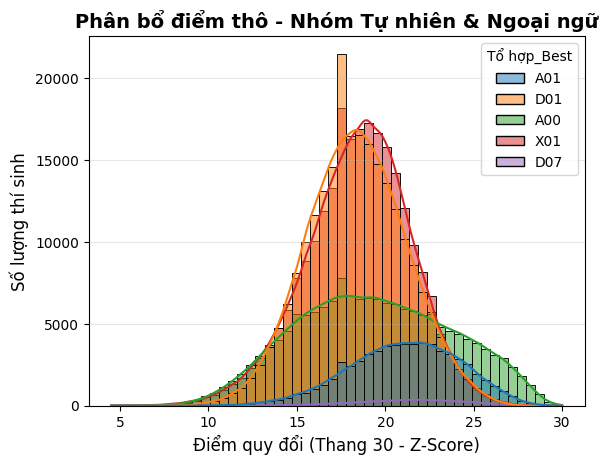

In [13]:
# TH1. Danh sách tổ hợp: [A00, A01, D01, D07, X01]

df_th1 = raw_score(df, ["A00", "A01", "D01", "D07", "X01"]).collect().to_pandas()

sns.histplot(data=df_th1, x="Z_Max", hue="Tổ hợp_Best", kde=True, bins=50)
plt.title("Phân bổ điểm thô - Nhóm Tự nhiên & Ngoại ngữ", fontsize=14, fontweight='bold')
plt.xlabel("Điểm quy đổi (Thang 30 - Z-Score)", fontsize=12)
plt.ylabel("Số lượng thí sinh", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

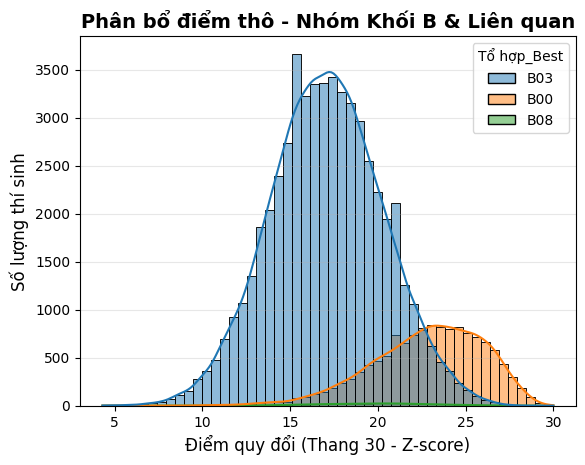

In [14]:
# TH2. Danh sách tổ hợp: [B00, B03, B08]

df_th2 = raw_score(df, ["B00", "B03", "B08"]).collect().to_pandas()

sns.histplot(data=df_th2, x="Z_Max", hue="Tổ hợp_Best", kde=True, bins=50)
plt.title("Phân bổ điểm thô - Nhóm Khối B & Liên quan", fontsize=14, fontweight='bold')
plt.xlabel("Điểm quy đổi (Thang 30 - Z-score)", fontsize=12)
plt.ylabel("Số lượng thí sinh", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

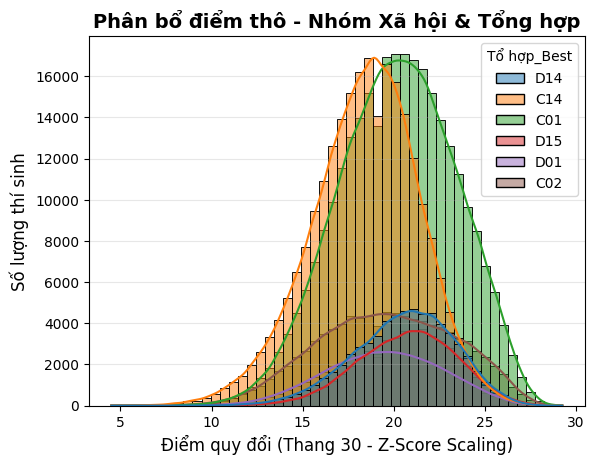

In [15]:
# TH3. Danh sách tổ hợp: [C01, C02, C14, D01, D14, D15]

df_th3 = raw_score(df, ["C01", "C02", "C14", "D01", "D14", "D15"]).collect().to_pandas()

sns.histplot(data=df_th3, x="Z_Max", hue="Tổ hợp_Best", kde=True, bins=50)
plt.title("Phân bổ điểm thô - Nhóm Xã hội & Tổng hợp", fontsize=14, fontweight='bold')
plt.xlabel("Điểm quy đổi (Thang 30 - Z-Score Scaling)", fontsize=12)
plt.ylabel("Số lượng thí sinh", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Z-score

In [16]:
def z_score(df : pl.LazyFrame, combs : list[str]) -> pl.LazyFrame:
    # B1: Lọc điều kiện
    df_filtered = (
        df.filter(
            (pl.col("Tổ hợp").is_in(combs)) &
            (pl.col("Hợp lệ") == True)
        )
        .select(["SOBAODANH", "Tổ hợp", "Tổng điểm"])
    )

    # B2: Tính toán 2 chỉ số thống kê (cho từng tổ hợp)
    stat_table = (
        df_filtered
            .group_by("Tổ hợp")
            .agg([
            pl.col("Tổng điểm").mean().alias("Trung bình"),
            pl.col("Tổng điểm").std().alias("Độ lệch chuẩn")
        ])
    )

    # B2.5: [FIXED] Đặt alias để tránh DuplicateError 'Tổng điểm'
    global_stats = df_filtered.select([
        pl.col("Tổng điểm").mean().alias("g_mean"),
        pl.col("Tổng điểm").std().alias("g_std")
    ]).collect()

    g_mean = global_stats[0, "g_mean"]
    g_std = global_stats[0, "g_std"]

    # B3: Nối 2 bảng đó
    stat_df = df_filtered.join(
        stat_table,
        on = "Tổ hợp",
        how = "left"
    )

    # B4: Áp dụng công thức quy đổi
    return (
        stat_df.with_columns(
            # 1. Tạo cột Z-score trước
            z_score_val = (pl.col("Tổng điểm") - pl.col("Trung bình")) / pl.col("Độ lệch chuẩn")
        )
        .with_columns(
            # 2. Quy đổi về thang điểm chung của kỳ thi (Thang 30)
            (g_mean + pl.col("z_score_val").fill_nan(0) * g_std)
            .clip(0, 30)
            .alias("Điểm quy đổi")
        )
        .drop(["Trung bình", "Độ lệch chuẩn", "Tổng điểm", "z_score_val"])
        .group_by("SOBAODANH")
        .agg([
            pl.col("Điểm quy đổi").max().alias("Z_Max"),
            pl.col("Tổ hợp").sort_by("Điểm quy đổi").last().alias("Tổ hợp_Best")
        ])
    )

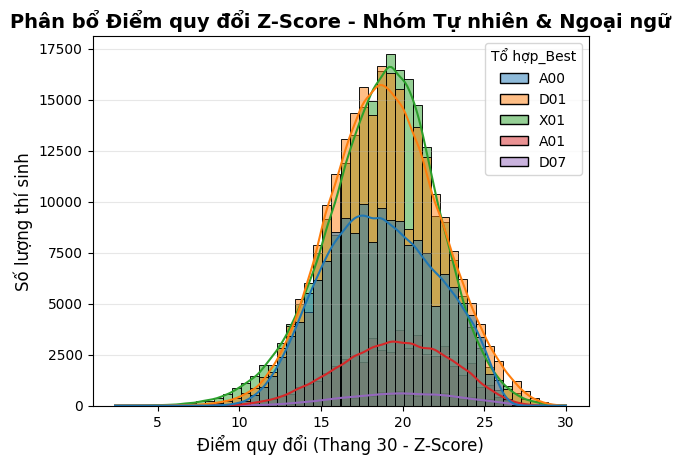

In [17]:
# TH1. Danh sách tổ hợp: [A00, A01, D01, D07, X01]

df_th1 = z_score(df, ["A00", "A01", "D01", "D07", "X01"]).collect().to_pandas()

sns.histplot(data=df_th1, x="Z_Max", hue="Tổ hợp_Best", kde=True, bins=50)
plt.title("Phân bổ Điểm quy đổi Z-Score - Nhóm Tự nhiên & Ngoại ngữ", fontsize=14, fontweight='bold')
plt.xlabel("Điểm quy đổi (Thang 30 - Z-Score)", fontsize=12)
plt.ylabel("Số lượng thí sinh", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

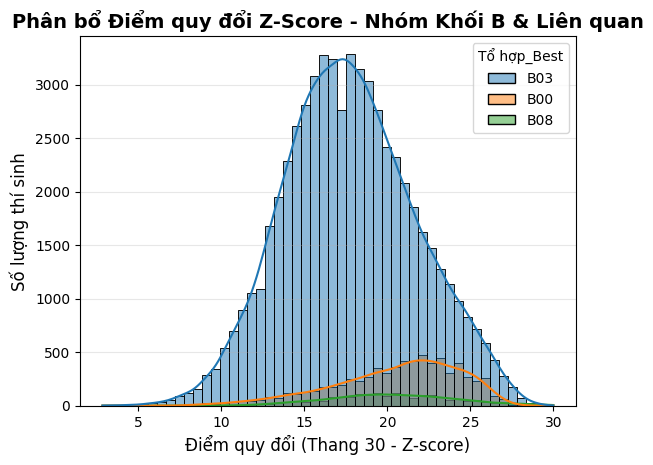

In [18]:
# TH2. Danh sách tổ hợp: [B00, B03, B08]

df_th2 = z_score(df, ["B00", "B03", "B08"]).collect().to_pandas()

sns.histplot(data=df_th2, x="Z_Max", hue="Tổ hợp_Best", kde=True, bins=50)
plt.title("Phân bổ Điểm quy đổi Z-Score - Nhóm Khối B & Liên quan", fontsize=14, fontweight='bold')
plt.xlabel("Điểm quy đổi (Thang 30 - Z-score)", fontsize=12)
plt.ylabel("Số lượng thí sinh", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

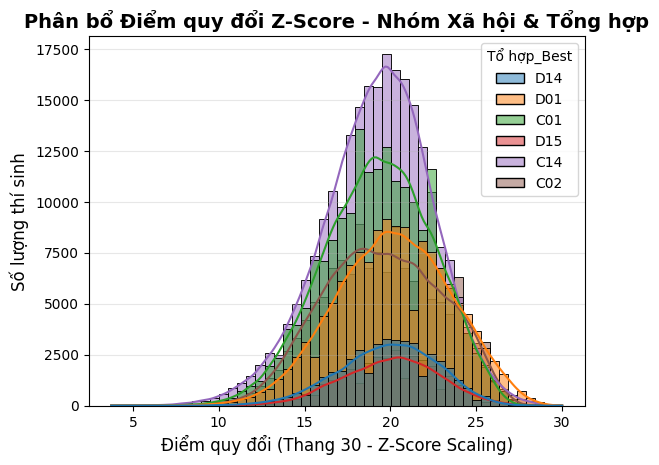

In [19]:
# TH3. Danh sách tổ hợp: [C01, C02, C14, D01, D14, D15]

df_th3 = z_score(df, ["C01", "C02", "C14", "D01", "D14", "D15"]).collect().to_pandas()

sns.histplot(data=df_th3, x="Z_Max", hue="Tổ hợp_Best", kde=True, bins=50)
plt.title("Phân bổ Điểm quy đổi Z-Score - Nhóm Xã hội & Tổng hợp", fontsize=14, fontweight='bold')
plt.xlabel("Điểm quy đổi (Thang 30 - Z-Score Scaling)", fontsize=12)
plt.ylabel("Số lượng thí sinh", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Robust

In [20]:
def robust(df : pl.LazyFrame, combs : list[str]) -> pl.LazyFrame:
    # 1. Lọc và chuẩn bị dữ liệu gốc
    df_base = (
        df.filter(
            (pl.col("Hợp lệ") == True) &
            (pl.col("Tổ hợp").is_in(combs))
        )
        .select(["SOBAODANH", "Tổ hợp", "Tổng điểm"])
    )


    # 2. Tính Q1, Median (Q2), Q3 cho từng tổ hợp
    stat_group = (
        df_base
        .group_by("Tổ hợp")
        .agg([
            pl.col("Tổng điểm").quantile(0.25).alias("q1_group"),
            pl.col("Tổng điểm").median().alias("q2_group"),
            pl.col("Tổng điểm").quantile(0.75).alias("q3_group")
        ])
        .with_columns(
            (pl.col("q3_group") - pl.col("q1_group")).alias("iqr_group")
        )
    )


    # 3. Tính Median và IQR của toàn bộ tập dữ liệu (Global)
    stat_global = (
        df_base
        .select([
            pl.col("Tổng điểm").median().alias("g_q2"),
            pl.col("Tổng điểm").quantile(0.25).alias("g_q1"),
            pl.col("Tổng điểm").quantile(0.75).alias("g_q3")
        ])
        .with_columns(
            (pl.col("g_q3") - pl.col("g_q1")).alias("g_iqr")
        )
    )


    # 4. Join các thông số vào bảng chính
    merged_df = (
        df_base
        .join(stat_group, on="Tổ hợp", how="left")
        .join(stat_global, how="cross")
    )


    # 5. Áp dụng công thức Robust Scaler và Aggregation
    final_df = (
        merged_df.with_columns(
            # Công thức Robust: (x - Q2) / IQR
            # Xử lý trường hợp IQR = 0 để tránh lỗi chia cho 0
            robust_val = pl.when(pl.col("iqr_group") > 0)
                        .then((pl.col("Tổng điểm") - pl.col("q2_group")) / pl.col("iqr_group"))
                        .otherwise(0.0)
        )
        .with_columns(
            # Quy đổi về thang 30 dựa trên hệ quy chiếu Global Robust
            # Công thức: g_q2 + robust_val * g_iqr
            (pl.col("g_q2") + pl.col("robust_val").fill_nan(0) * pl.col("g_iqr"))
            .clip(0, 30)
            .alias("Điểm quy đổi")
        )
        .group_by("SOBAODANH")
        .agg([
            pl.col("Điểm quy đổi").max().alias("Z_Max"),
            pl.col("Tổ hợp").sort_by("Điểm quy đổi").last().alias("Tổ hợp_Best")
        ])
    )

    return final_df

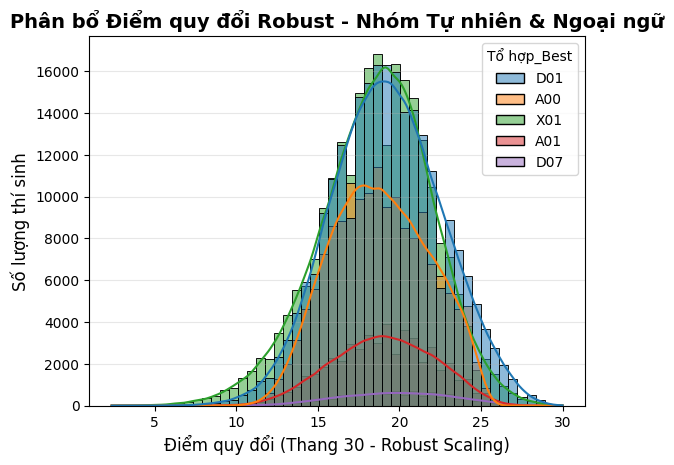

In [21]:
# TH1. Danh sách tổ hợp: [A00, A01, D01, D07, X01]

df_th1 = robust(df, ["A00", "A01", "D01", "D07", "X01"]).collect().to_pandas()

sns.histplot(data=df_th1, x="Z_Max", hue="Tổ hợp_Best", kde=True, bins=50)
plt.title("Phân bổ Điểm quy đổi Robust - Nhóm Tự nhiên & Ngoại ngữ", fontsize=14, fontweight='bold')
plt.xlabel("Điểm quy đổi (Thang 30 - Robust Scaling)", fontsize=12)
plt.ylabel("Số lượng thí sinh", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

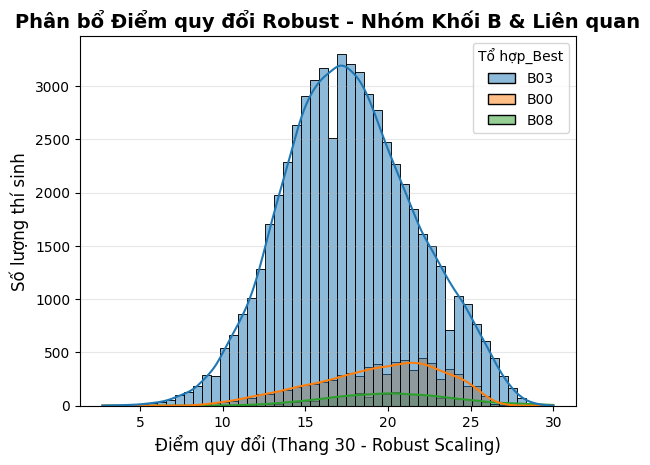

In [22]:
# TH2. Danh sách tổ hợp: [B00, B03, B08]

df_th2 = robust(df, ["B00", "B03", "B08"]).collect().to_pandas()

sns.histplot(data=df_th2, x="Z_Max", hue="Tổ hợp_Best", kde=True, bins=50)
plt.title("Phân bổ Điểm quy đổi Robust - Nhóm Khối B & Liên quan", fontsize=14, fontweight='bold')
plt.xlabel("Điểm quy đổi (Thang 30 - Robust Scaling)", fontsize=12)
plt.ylabel("Số lượng thí sinh", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

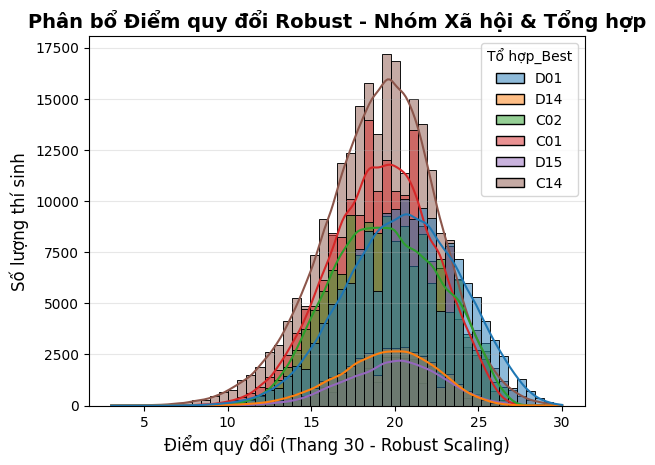

In [23]:
# TH3. Danh sách tổ hợp: [C01, C02, C14, D01, D14, D15]

df_th3 = robust(df, ["C01", "C02", "C14", "D01", "D14", "D15"]).collect().to_pandas()

sns.histplot(data=df_th3, x="Z_Max", hue="Tổ hợp_Best", kde=True, bins=50)
plt.title("Phân bổ Điểm quy đổi Robust - Nhóm Xã hội & Tổng hợp", fontsize=14, fontweight='bold')
plt.xlabel("Điểm quy đổi (Thang 30 - Robust Scaling)", fontsize=12)
plt.ylabel("Số lượng thí sinh", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Kết luận:

### **1. Đánh giá sự phân hóa dữ liệu thô (Raw Scores)**

- Qua 3 nhóm ngành (Tự nhiên, Khối B, Xã hội), dữ liệu thô cho thấy một "Statistical Bias" (Độ lệch thống kê) lớn:
    - Các tổ hợp như A00, A01 có đỉnh phân phối lệch phải
    - trong khi D01 và nhóm Khối B thường có xu hướng tập trung mật độ cao ở vùng điểm trung bình.
- Điều này chứng minh rằng việc so sánh trực tiếp điểm thô giữa các khối thi là không hợp lệ do sự khác biệt về độ khó đặc thù của từng môn thành phần.

### **2. So sánh hiệu quả thực nghiệm (Empirical Comparison)**

Việc quan sát đồng thời 9 biểu đồ cho phép chúng ta đánh giá các phương pháp xử lý:

* Z-Score (Standardization):
    - Kết quả: Đưa được các nhóm về cùng Mean ($\mu = 0$).
    - Vấn đề: Nhìn vào các "tails" (đuôi) của phân phối ở nhóm Xã hội và Khối B, Z-Score vẫn bị kéo giãn do ảnh hưởng của các thí sinh bỏ thi hoặc điểm liệt. Điều này làm cho độ lệch chuẩn ($\sigma$) bị nhiễu.
* Robust Scaling (Optimal Approach):
    - Kết quả: Đây là phương pháp "Clean" nhất. Bằng cách sử dụng Median và IQR, nó ép các "đỉnh" của 9 biểu đồ về cùng một vị trí mà không làm biến dạng cấu trúc dữ liệu của nhóm đa số.
    - Nhận định: Robust Scaling giúp hệ thống Dashboard hiển thị vị thế thực sự của thí sinh, loại bỏ hoàn toàn "outliers" (những dòng dữ liệu rác/biến động cực đoan).

### **3. Giá trị vận hành hệ thống (System Implementation)**

- Performance: Toàn bộ quá trình Scale và Visualize 9 kịch bản trên hơn 5 triệu dòng dữ liệu được thực hiện qua Polars LazyFrame API. Việc tối ưu hóa ở tầng "Query Plan" giúp hệ thống giữ được phản hồi nhanh (Low Latency) ngay cả khi thực hiện các phép toán thống kê phức tạp.
- Data Integration: Các cột dữ liệu chuẩn hóa này sẽ là Features chính cho các thuật toán gợi ý trường đại học và dự báo biến động điểm chuẩn trên Dashboard.